In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.datasets import make_moons

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import GridSearchCV

In [12]:
X,y = make_classification(

    n_samples=12000,

    n_features=20,

    n_informative=15,

    n_redundant=3,

    n_classes=4,

    n_clusters_per_class=1,

    random_state=42

)

In [13]:
df = pd.DataFrame(

    X,

    columns=[f"Feature_{i}" for i in range(20)]

)

df["Target"] = y

df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Target
0,-6.739852,2.367167,-0.028208,0.515388,1.871897,7.382320,-1.518541,-0.099684,-1.118523,0.003215,...,0.161280,2.486091,7.585826,-0.268566,-2.812899,2.701317,4.883812,0.526748,-7.213242,2
1,-0.761467,0.876357,-2.735765,0.143278,2.502088,-3.800537,-3.458751,0.045283,3.866356,3.331206,...,-2.284807,0.488533,-2.005530,0.741363,-1.812394,-0.069061,0.272048,0.364897,-0.556168,3
2,-1.561047,-3.077821,-2.183197,-0.604248,-0.301903,0.352356,-0.589826,-0.400732,0.500472,1.395826,...,-0.643295,0.815895,-0.002147,0.446171,0.476546,1.300700,1.389933,-0.916904,-1.025130,0
3,5.584050,2.834345,1.060759,0.977653,7.139092,-1.237327,-3.245415,-1.391666,1.184380,-0.303297,...,1.751119,5.076642,1.041834,3.854747,-4.170878,-1.319503,1.904953,0.057459,-4.748760,2
4,-0.473856,2.067197,-0.993835,0.669807,-0.105156,4.284974,1.712718,-1.341485,-1.222590,0.544932,...,2.300043,-3.918965,-1.249889,-1.760435,1.449541,-0.001638,-1.659732,7.002983,-2.020864,2


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_0   12000 non-null  float64
 1   Feature_1   12000 non-null  float64
 2   Feature_2   12000 non-null  float64
 3   Feature_3   12000 non-null  float64
 4   Feature_4   12000 non-null  float64
 5   Feature_5   12000 non-null  float64
 6   Feature_6   12000 non-null  float64
 7   Feature_7   12000 non-null  float64
 8   Feature_8   12000 non-null  float64
 9   Feature_9   12000 non-null  float64
 10  Feature_10  12000 non-null  float64
 11  Feature_11  12000 non-null  float64
 12  Feature_12  12000 non-null  float64
 13  Feature_13  12000 non-null  float64
 14  Feature_14  12000 non-null  float64
 15  Feature_15  12000 non-null  float64
 16  Feature_16  12000 non-null  float64
 17  Feature_17  12000 non-null  float64
 18  Feature_18  12000 non-null  float64
 19  Feature_19  12000 non-nul

In [15]:
df.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Target
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,-0.012301,-0.005098,-0.494703,-0.002088,0.494021,-0.550348,-0.022954,-0.019179,-0.023784,0.510222,...,-0.499693,0.520138,-0.470845,0.473796,-0.507901,-0.481837,0.518893,-0.016768,-0.561145,1.500500
std,2.421367,2.300138,2.539283,1.006790,2.614494,4.513541,2.523246,1.005743,2.190971,2.510091,...,2.412762,2.351069,2.453909,2.534804,2.247044,2.556150,2.426715,2.452177,3.731456,1.117931
min,-11.769542,-9.245820,-10.526464,-3.616559,-9.898960,-16.234323,-8.659936,-3.951743,-8.322095,-9.658962,...,-10.026795,-9.859727,-10.072749,-9.423916,-8.416064,-9.292711,-7.560404,-10.082494,-15.641912,0.000000
25%,-1.633785,-1.551738,-2.202090,-0.673924,-1.258651,-3.574393,-1.767301,-0.708254,-1.494922,-1.118501,...,-2.119002,-0.931036,-2.149694,-1.220061,-2.035203,-2.233461,-1.146728,-1.666659,-3.046785,1.000000
50%,0.035258,-0.008899,-0.585253,-0.002100,0.521533,-0.633467,-0.075090,-0.020603,0.005075,0.561219,...,-0.510390,0.628370,-0.498879,0.540763,-0.487493,-0.543951,0.487111,-0.022766,-0.471074,1.500000
75%,1.643462,1.547198,1.173047,0.668376,2.287399,2.396435,1.667747,0.665950,1.470819,2.193933,...,1.162003,2.078830,1.189554,2.217893,1.059214,1.165293,2.151322,1.639597,2.002339,3.000000
max,9.276449,8.442338,10.422903,4.253332,10.460182,17.829419,10.623705,3.504065,7.656873,9.318027,...,9.084230,9.378422,9.342492,9.038199,8.267735,10.752933,10.831061,8.835162,12.381181,3.000000


In [16]:
df["Target"].value_counts()

Target
1    3004
3    3002
2    2998
0    2996
Name: count, dtype: int64

In [17]:
X = df.drop("Target",axis=1)

y = df["Target"]

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Softmax Regression

In [33]:
softmax = LogisticRegression(

    max_iter=1000,
    solver="lbfgs"

)

softmax.fit(X_train, y_train)

softmax_pred = softmax.predict(X_test)

In [34]:
softmax_pred = softmax.predict(X_test)

In [35]:
print("Softmax Accuracy :",

      accuracy_score(y_test,softmax_pred))

Softmax Accuracy : 0.8616666666666667


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

ovr = OneVsRestClassifier(
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    )
)

ovr.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](4,)","[0,1,2,3]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...max_iter=1000), LogisticRegre...max_iter=1000), LogisticRegre...max_iter=1000), LogisticRegre...max_iter=1000)]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,20
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000


In [37]:
ovr_pred = ovr.predict(X_test)

In [38]:
print("OvR Accuracy :",

      accuracy_score(y_test,ovr_pred))

OvR Accuracy : 0.8475


In [39]:
comparison = pd.DataFrame({

    "Model":[

        "Softmax",

        "One-vs-Rest"

    ],

    "Accuracy":[

        accuracy_score(y_test,softmax_pred),

        accuracy_score(y_test,ovr_pred)

    ]

})

comparison

,Model,Accuracy
0,Softmax,0.861667
1,One-vs-Rest,0.847500


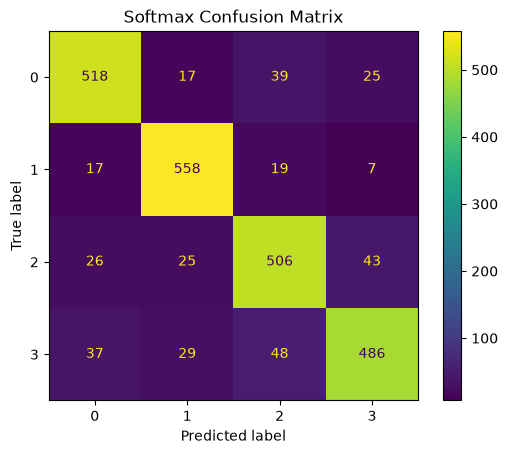

In [40]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    softmax_pred

)

plt.title("Softmax Confusion Matrix")

plt.show()

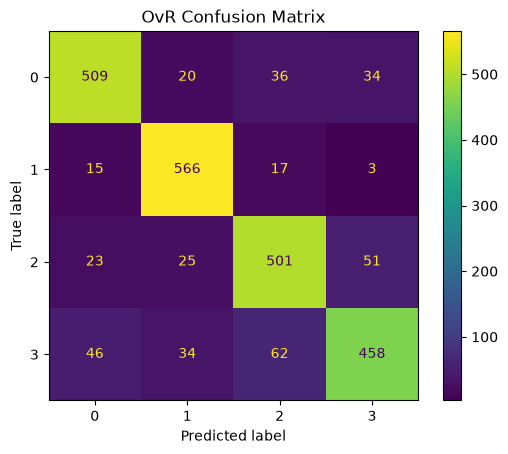

In [41]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    ovr_pred

)

plt.title("OvR Confusion Matrix")

plt.show()

In [42]:
print(classification_report(

    y_test,

    softmax_pred

))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87       599
           1       0.89      0.93      0.91       601
           2       0.83      0.84      0.83       600
           3       0.87      0.81      0.84       600

    accuracy                           0.86      2400
   macro avg       0.86      0.86      0.86      2400
weighted avg       0.86      0.86      0.86      2400



# Polynomial Features

In [51]:
X,y = make_moons(

    n_samples=2000,

    noise=0.30,

    random_state=42

)

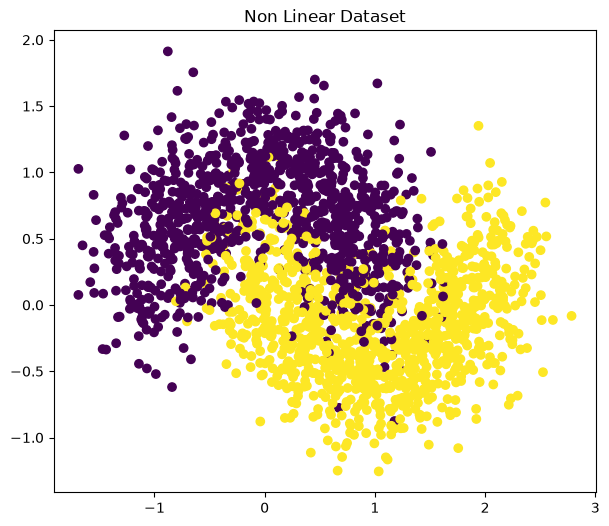

In [52]:
plt.figure(figsize=(7,6))

plt.scatter(

    X[:,0],

    X[:,1],

    c=y

)

plt.title("Non Linear Dataset")

plt.show()

In [53]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [55]:
linear_model = LogisticRegression()

linear_model.fit(

    X_train,

    y_train

)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
linear_pred = linear_model.predict(

    X_test

)

In [57]:
print(

    accuracy_score(

        y_test,

        linear_pred

    )

)

0.8575


In [58]:
poly = PolynomialFeatures(

    degree=3,

    include_bias=False

)

X_train_poly = poly.fit_transform(

    X_train

)

X_test_poly = poly.transform(

    X_test

)

In [59]:
poly_model = LogisticRegression(

    max_iter=2000

)

poly_model.fit(

    X_train_poly,

    y_train

)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [60]:
poly_pred = poly_model.predict(

    X_test_poly

)

In [61]:
print(

    accuracy_score(

        y_test,

        poly_pred

    )

)

0.9125


In [62]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Logistic",

        "Polynomial Logistic"

    ],

    "Accuracy":[

        accuracy_score(

            y_test,

            linear_pred

        ),

        accuracy_score(

            y_test,

            poly_pred

        )

    ]

})

comparison

,Model,Accuracy
0,Linear Logistic,0.8575
1,Polynomial Logistic,0.9125


# Hyperparameter Tuning

In [63]:
param_grid = {

    "C":[

        0.01,

        0.1,

        1,

        10,

        100

    ],

    "penalty":[

        "l2"

    ],

    "solver":[

        "lbfgs",

        "newton-cg",

        "sag"

    ]

}

In [64]:
grid = GridSearchCV(

    LogisticRegression(

        max_iter=3000

    ),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(

    X_train_poly,

    y_train

)

C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=3000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

In [65]:
print(

    grid.best_params_

)

{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [66]:
print(

    grid.best_score_

)

0.9200000000000002


In [67]:
best_model = grid.best_estimator_

In [68]:
best_model = grid.best_estimator_

In [69]:
best_pred = best_model.predict(

    X_test_poly

)

In [70]:
print(

    accuracy_score(

        y_test,

        best_pred

    )

)

0.905
